In [1]:
# Step 1 — Import Libraries

import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
# Step 2 — Load Dataset

dataset_url="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir=tf.keras.utils.get_file(origin=dataset_url,untar=True)
data_dir=os.path.join(data_dir,"flower_photos")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
# Step 3 — Create Data Loaders

img_size=(224,224)
batch_size=32

training_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [4]:
validation_data=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [5]:
# Step 4 — Get Class Names

class_names=training_data.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [6]:
# Step 5 — Normalize Data

normalization_layer=layers.Rescaling(1./255)

training_data=training_data.map(lambda x,y:(normalization_layer(x),y))
validation_data=validation_data.map(lambda x,y:(normalization_layer(x),y))

In [7]:
# Step 6 — Load Pretrained MobileNet

base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False, #removes classification layers bcs mobilenet was trained on 1000 classes..we only need custom 5 classes
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
# Step 7 — Freeze the model

base_model.trainable=False

In [9]:
# Step 8 — Build Custom Model

model=keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names),activation="softmax")
])

In [13]:
# Step 9- Compile model

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# Step 10 — Train Model

history=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 208ms/step - accuracy: 0.9629 - loss: 0.1052 - val_accuracy: 0.9019 - val_loss: 0.3482
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9581 - loss: 0.1111 - val_accuracy: 0.8883 - val_loss: 0.3586
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.9731 - loss: 0.0832 - val_accuracy: 0.9033 - val_loss: 0.3534
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9731 - loss: 0.0730 - val_accuracy: 0.9033 - val_loss: 0.3466
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9755 - loss: 0.0696 - val_accuracy: 0.9005 - val_loss: 0.3928
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9748 - loss: 0.0677 - val_accuracy: 0.9074 - val_loss: 0.4001
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9802 - loss: 0.0609 - val_accuracy: 0.9074 - val_loss: 0.3716
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.9813 - loss: 0.0518 - val_accuracy: 0.8965

In [19]:
# Step 11 — Fine-Tuning

base_model.trainable=True
for layer in base_model.layers[:-20]:
  layer.trainable=False

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)
history1=model.fit(
    training_data,
    validation_data=validation_data,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.9288 - loss: 0.2079 - val_accuracy: 0.9046 - val_loss: 0.4049
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9697 - loss: 0.0961 - val_accuracy: 0.8992 - val_loss: 0.4342
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9823 - loss: 0.0623 - val_accuracy: 0.9087 - val_loss: 0.4258
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9850 - loss: 0.0476 - val_accuracy: 0.9019 - val_loss: 0.4118
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.8992 - val_loss: 0.5055
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9905 - loss: 0.0301 - val_accuracy: 0.9074 - val_loss: 0.3933
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9908 - loss: 0.0325 - val_accuracy: 0.9155 - val_loss: 0.3907
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9932 - loss: 0.0232 - val_accuracy: 0.9142 

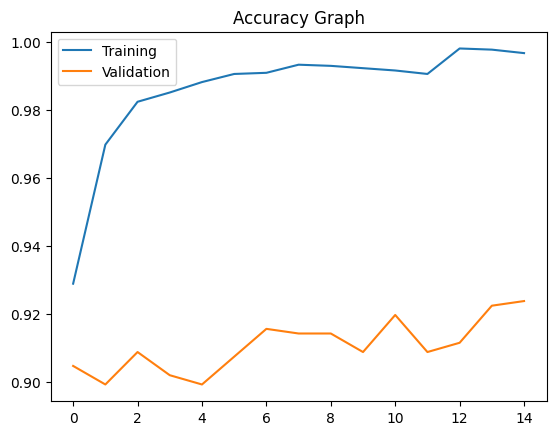

In [28]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.legend(['Training','Validation'])
plt.title('Accuracy Graph')
plt.show()

In [46]:
# Predict new image

import cv2
img=cv2.imread("/content/flower4.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(224,224))
img=img/255.0
img=np.expand_dims(img,axis=0)
img.shape

(1, 224, 224, 3)

In [47]:
y_pred=model.predict(img)
y_pred=np.argmax(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


np.int64(1)

In [48]:
print("Predictions:",class_names[y_pred])

Predictions: dandelion
